## Spotify Preprocessing & Exploratory Data Analysis (EDA)

### 1. Setup & Data Loading

#### 1.1 Setup

In [118]:
import os 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

DATA_PATH = "../data/raw/spotify_tracks.csv"    # adjust if notebook path differs

#### 1.2 Data Loading

In [119]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display first few rows of the dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


#### 1.3 Initial Data Inspection

In [120]:
shape = df.shape
print(f"Dataset shape: {shape}")

print()

# Display column names and data types
print(df.info())


Dataset shape: (114000, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  floa

In [121]:
print("Basic Statistics:")

# Display basic statistics
print(df.describe())

Basic Statistics:
          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.472000    

### 2. Data Cleaning & Preprocessing

#### 2.1 Missing Values

In [122]:
# Check for missing values, return 1 if original value is missing; 0 otherwise
print("Attributes with missing values:")
print("1 if missing, 0 otherwise")
print()
print(df.isnull().sum())

Attributes with missing values:
1 if missing, 0 otherwise

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [123]:
# Drop rows with missing values 
original_rows = len(df)

df = df.dropna()
print(f"Number of rows before dropping missing values: {original_rows}")
print(f"Number of rows after dropping missing values: {len(df)}")

print()



Number of rows before dropping missing values: 114000
Number of rows after dropping missing values: 113999



In [124]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


#### 2.2 Creating `viral` Target

- `viral = 1` if popularity > 50, else `0`

In [125]:
df["viral"] = (df["popularity"] > 50).astype(int)
df["viral"].value_counts(), df["viral"].value_counts(normalize=True)

(viral
 0    86229
 1    27770
 Name: count, dtype: int64,
 viral
 0    0.756401
 1    0.243599
 Name: proportion, dtype: float64)

**Total Count:**  
- `non-viral` = 86,229 tracks
- `viral` = 27,770 tracks

As seen from the above output, around 75.6% are non-viral, with 24.3% being viral.

### 3. EDA

#### 3.1 Artist with Most Number of Tracks

In [126]:
df_artist = df.groupby(['artists']).size().rename("count").to_frame()
df_artist.sort_values(by="count", ascending=False)

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
...,...
Mother Love Bone,1
DubVision;Afrojack,1
Dub Pistols;Too Many T's,1


In [127]:
df_artist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31437 entries, !nvite to 龍藏Ryuzo
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   count   31437 non-null  int64
dtypes: int64(1)
memory usage: 491.2+ KB


#### 3.2 Genre with Most Number of Tracks

In [128]:
df_genre = df.groupby(['track_genre']).size().rename("count").to_frame()
df_genre.sort_values(by="count", ascending=False)


,count
track_genre,
acoustic,1000
afrobeat,1000
psych-rock,1000
progressive-house,1000
power-pop,1000
...,...
emo,1000
electronic,1000
electro,1000


#### 3.2 Univariate Analysis

##### Popularity Distribution

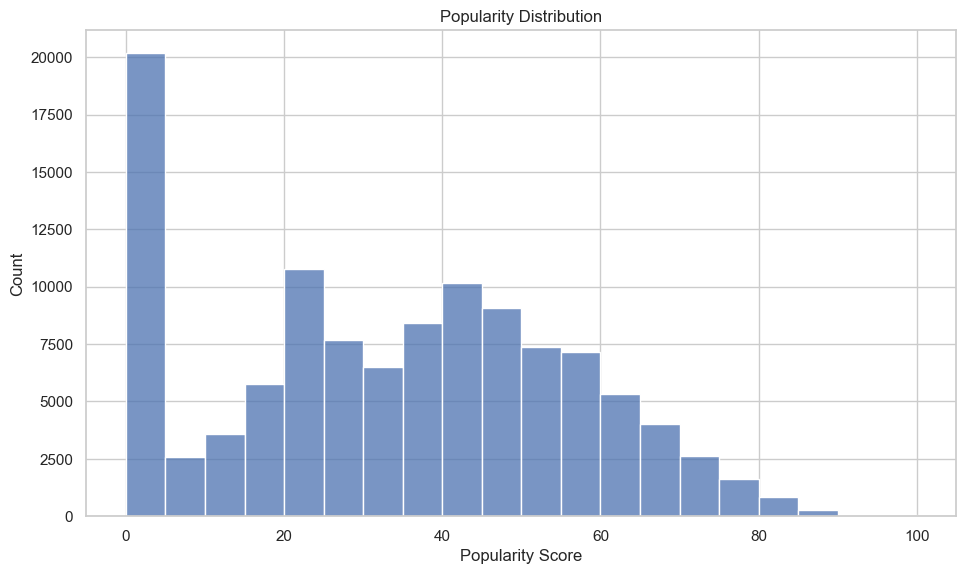

In [129]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=20, kde=False)
plt.title('Popularity Distribution')
plt.xlabel('Popularity Score')
plt.ylabel('Count')
plt.show()

#### Distribution of Key Audio Features

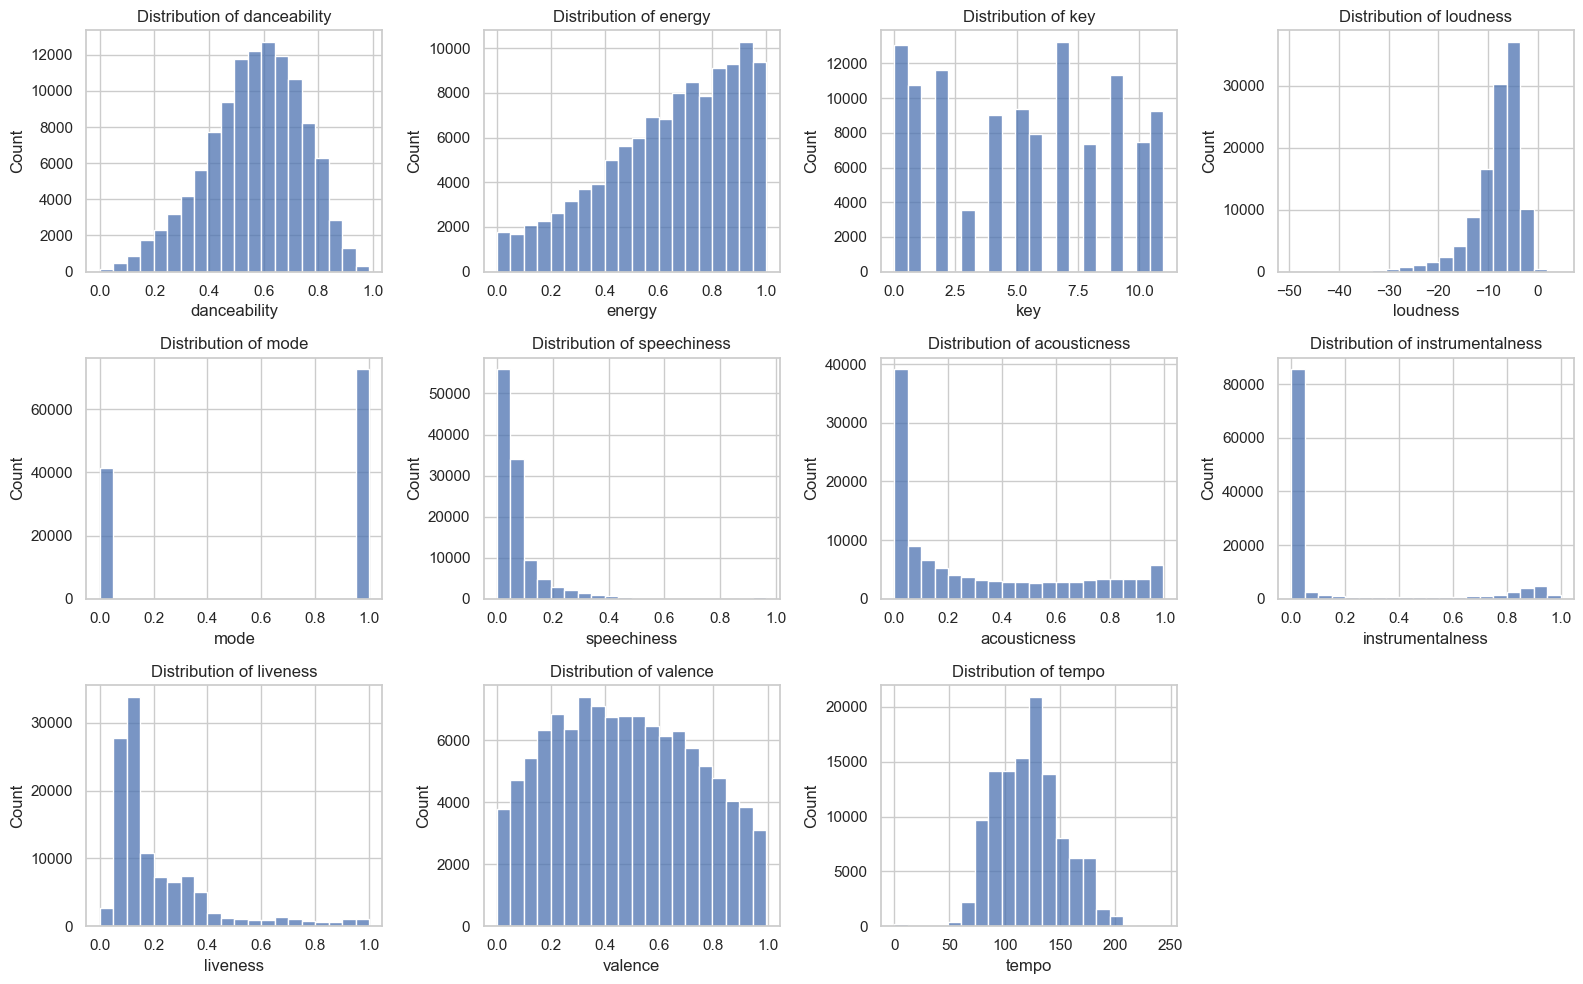

In [130]:
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Create subplots for each audio feature
n_rows, m_cols = 3, 4
fig, axes = plt.subplots(n_rows, m_cols, figsize=(16, 10))
axes = axes.flatten()

# Plot each audio feature
for i, feature in enumerate(audio_features):
    ax = axes[i]
    sns.histplot(df[feature], bins=20, kde=False, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

# Hide any unused subplots (if features < n_rows * m_cols)
for j in range(len(audio_features), n_rows * m_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




**INSERT ANY INFORMATION**

#### 3.3 Correlation Analysis

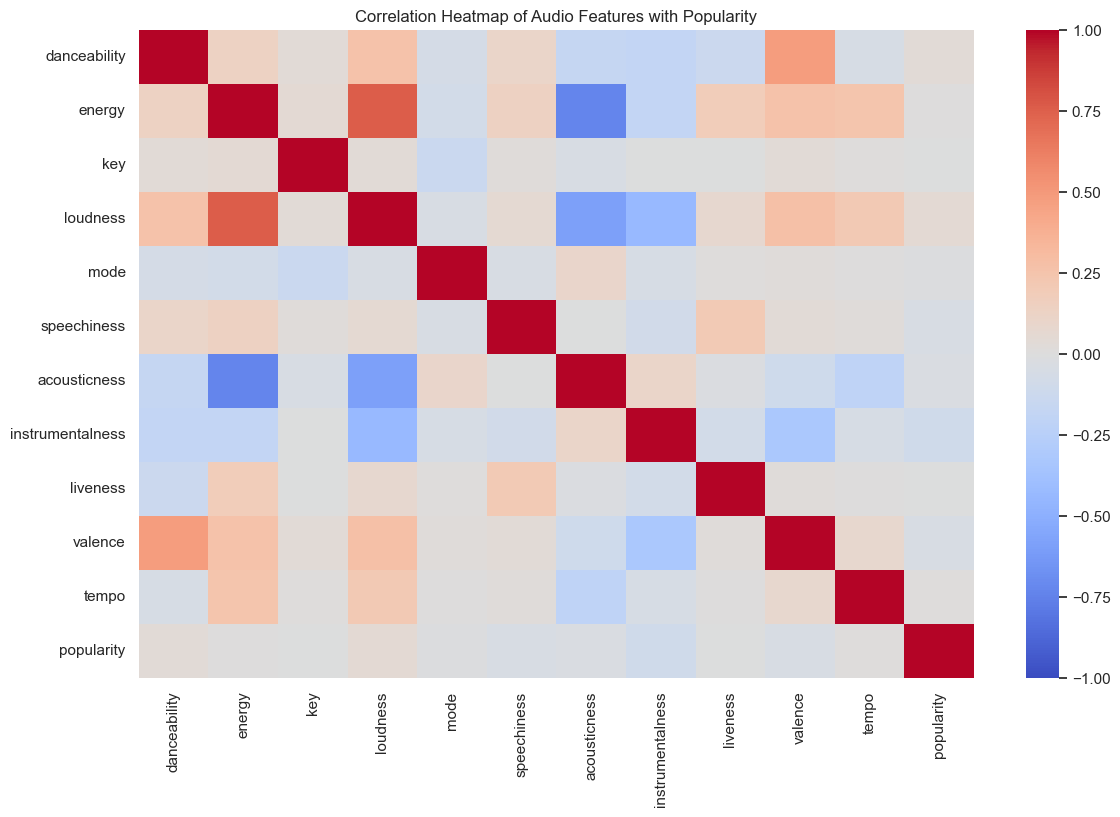

In [131]:
corr_matrix = df[audio_features + ['popularity']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap of Audio Features with Popularity')
plt.show()


**ANNOTATE**

1. energy <-> loudness
2. danceability <-> valence
3. acousticnes <-> energy
4. etc. 

#### 3.4 Scatter Plots

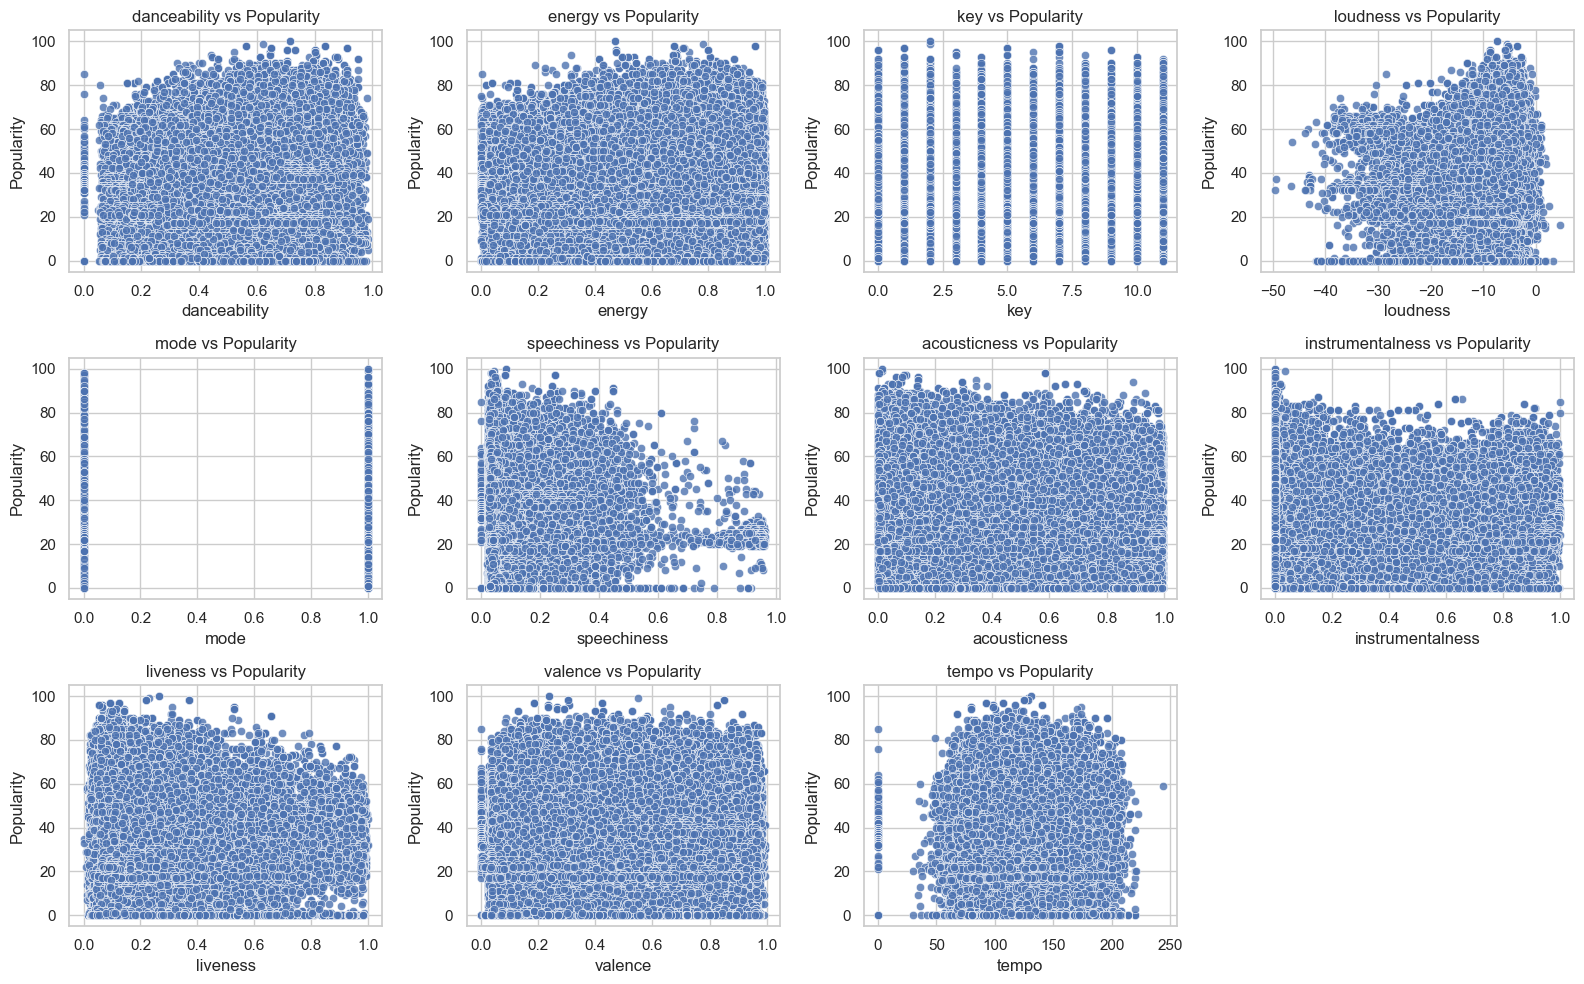

In [132]:
# For each audio feature, plot against popularity
fig, axes = plt.subplots(n_rows, m_cols, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    ax = axes[i]
    sns.scatterplot(x=feature, y='popularity', data=df, ax=ax, alpha=0.8)
    ax.set_title(f'{feature} vs Popularity')
    ax.set_xlabel(feature)
    ax.set_ylabel('Popularity')

# Hide any unused subplots (if features < n_rows * m_cols)
for j in range(len(audio_features), n_rows * m_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**ANNOTATE**

#### 3.5 Boxplots

Viral vs. Non-Viral Comparisons

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

def boxplot_with_green_red(df, feature, target_col="viral", labels=("Non‑viral", "Viral")):
    """
    Colors the group with higher median feature value as green, the other as red.
    Assumes target_col is binary 0/1.
    """
    medians = df.groupby(target_col)[feature].median()
    # Decide which label (0 or 1) is 'better' (higher median)
    better = medians.idxmax()      # 0 or 1
    worse  = 1 - better

    palette = {
        "0": "green" if better == 0 else "red",
        "1": "green" if better == 1 else "red",
    }

    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(data=df, x=target_col, y=feature, palette=palette)
    ax.set_xticklabels(labels)
    ax.set_title(f"{feature} by Virality\n(green = higher median)")
    plt.show()

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_19673/569189.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_19673/569189.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non‑viral", "Viral"])
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_19673/569189.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_19673/569189.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

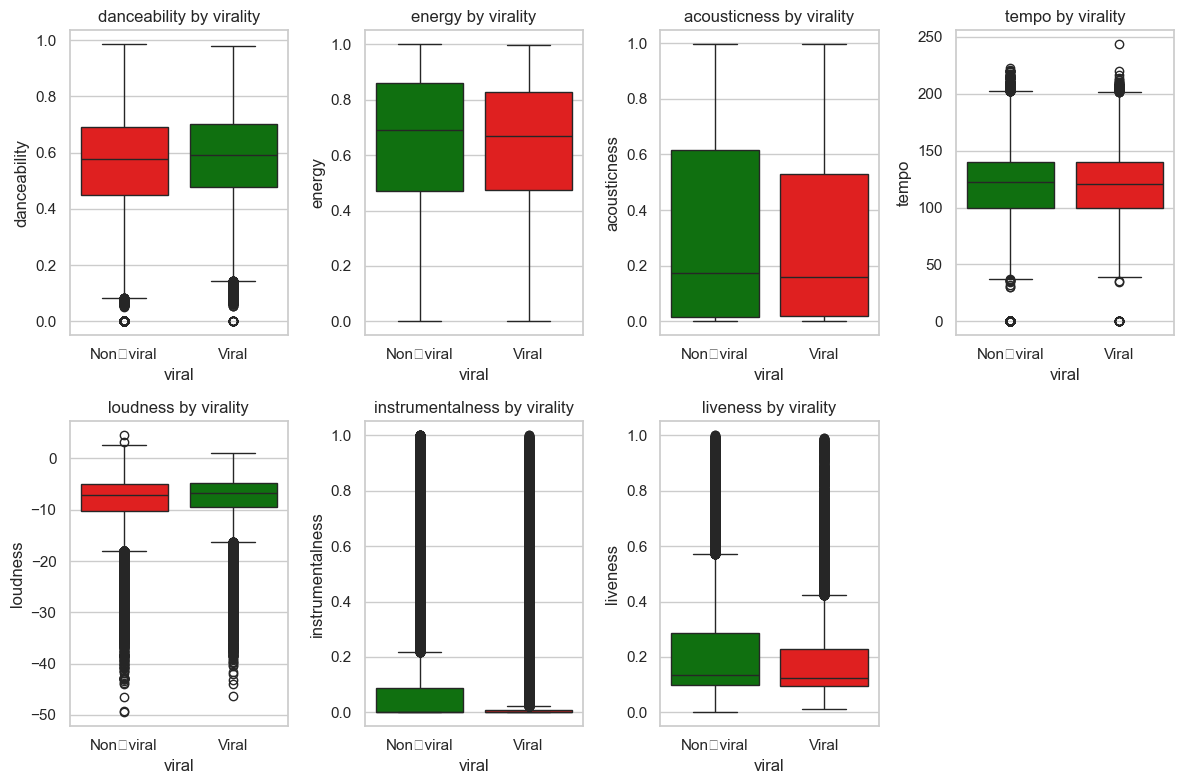

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["danceability", "energy", "acousticness", "tempo", "loudness", "instrumentalness", "liveness"]
n_rows, n_cols = 2, 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    # Compute which class has higher median for this feature
    medians = df.groupby("viral")[feature].median()
    better = medians.idxmax()        # 0 or 1

    # Palette: better group green, other red (string keys to be safe)
    better_key = str(better)
    palette = {
        "0": "green" if better_key == "0" else "red",
        "1": "green" if better_key == "1" else "red",
    }

    sns.boxplot(
        data=df,
        x="viral",
        y=feature,
        palette=palette,
        ax=ax
    )
    ax.set_title(f"{feature} by virality")
    ax.set_xticklabels(["Non‑viral", "Viral"])

# Hide any unused axes if features < n_rows * n_cols
for j in range(len(features), n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 4. Feature Engineering

#### 4.1 Feature Selection

Dataset will be save to: `data/processed` for necessary usage in modeling

In [135]:
df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name", "popularity"], axis=1)

print("Attributes kept:")
print(df.columns)


Attributes kept:
Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'viral'],
      dtype='object')


In [138]:
# Correlation with viral
popularity_correlation = (
    df.select_dtypes(include=[np.number])
      .corr()['viral']
      .drop('viral')
)

# Convert to list
pop_corr_list = popularity_correlation.values.tolist()
# Absolute value
pop_corr_list_abs = [abs(ele) for ele in pop_corr_list]

In [139]:
def average(l) -> float:
    """
    Calculate the average of a list

    Args:
        l (list): List of numbers

    Returns:
        float: Average of the list
    """
    return sum(l) / len(l)

# Average correlation
pop_corr_list_abs_avg = average(pop_corr_list_abs)

In [141]:
# Convert to dataframe
pop_corr_df = popularity_correlation.to_frame()

# Add absolute value of correlation
pop_corr_df['viral_abs'] = abs(pop_corr_df['viral'])

# Select features with correlation greater than average
pop_corr_abv = pop_corr_df[(pop_corr_df['viral_abs'] > pop_corr_list_abs_avg)]

# Sort by absolute value of correlation
pop_corr_abv = pop_corr_abv.sort_values(by=['viral_abs'], ascending=False)

pop_corr_abv.head()

,viral,viral_abs
liveness,-0.086908,0.086908
instrumentalness,-0.081801,0.081801
danceability,0.052040,0.052040
speechiness,-0.049383,0.049383
duration_ms,-0.040975,0.040975


**MIGHT NEED TO VISUALISE THE ABOVE CODE WITH SOME GRAPH**

#### 4.2 One-Hot Encoding

In [142]:
dummies_var = ['explicit', 'track_genre']

final_df = pd.get_dummies(df, prefix=dummies_var, columns=dummies_var, drop_first=True)

final_df.head()


,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,...,False,False,False,False,False,False,False,False,False,False
1,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,...,False,False,False,False,False,False,False,False,False,False
2,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,...,False,False,False,False,False,False,False,False,False,False
3,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,...,False,False,False,False,False,False,False,False,False,False
4,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,...,False,False,False,False,False,False,False,False,False,False


In [147]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Columns: 128 entries, duration_ms to track_genre_world-music
dtypes: bool(114), float64(9), int64(5)
memory usage: 25.4 MB


In [149]:
OUTPUT_PATH = "../data/processed/spotify_tracks_cleaned.csv"

os.makedirs("../data/processed", exist_ok=True)
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset saved to: {OUTPUT_PATH}")

Cleaned dataset saved to: ../data/processed/spotify_tracks_cleaned.csv
